Įkeliami ir paruošiami pradiniai duomenys.

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import warnings
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore")

DATA_DIR = Path(r"...")
DATA_FILE = DATA_DIR / "main_lentele_50_su_features.parquet"

main = pd.read_parquet(DATA_FILE)

main["DATE"] = pd.to_datetime(main["DATE"])

main = main.sort_values(
    ["STORE_ID", "SKU_GROUP", "SKU_ID", "DATE"]
).reset_index(drop=True)

main["unique_id"] = (
    main["STORE_ID"].astype(str)
    + "_"
    + main["SKU_GROUP"].astype(str)
    + "_"
    + main["SKU_ID"].astype(str)
)

main["ds"] = main["DATE"]
main["y"] = main["SALES_QTY"].astype(float)

Analizuojama nulinių pardavimų dalis laiko eilutėse.


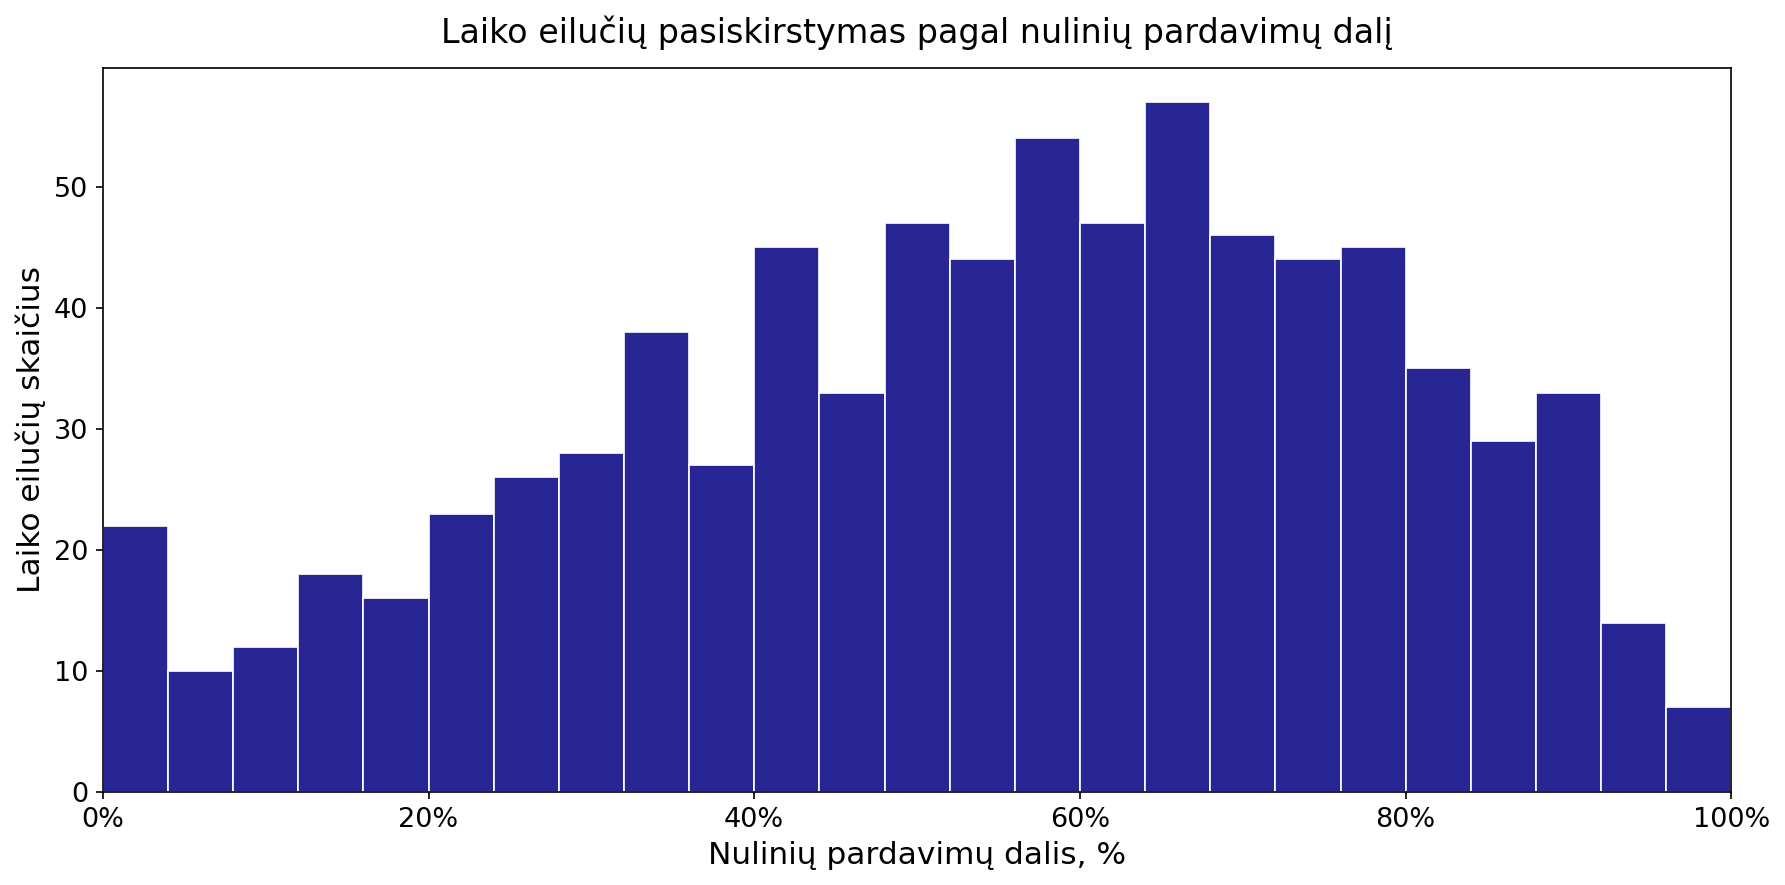

In [6]:
zero_by_series = (
    main
    .assign(is_zero=(main["y"] == 0).astype(int))
    .groupby("unique_id")
    .agg(
        n_days=("ds", "nunique"),
        zero_days=("is_zero", "sum"),
        mean_sales=("y", "mean"),
        median_sales=("y", "median"),
        max_sales=("y", "max")
    )
    .reset_index()
)
zero_by_series["zero_pct"] = zero_by_series["zero_days"] / zero_by_series["n_days"] * 100
plt.figure(figsize=(12, 6), dpi=150)
bin_edges = np.linspace(0, 100, 26)
plt.hist(
    zero_by_series["zero_pct"],
    bins=bin_edges,
    color="#100E8A",
    edgecolor="white",
    linewidth=0.9,
    alpha=0.9
)
plt.title("Laiko eilučių pasiskirstymas pagal nulinių pardavimų dalį", fontsize=16, pad=12)
plt.xlabel("Nulinių pardavimų dalis, %", fontsize=15)
plt.ylabel("Laiko eilučių skaičius", fontsize=15)
ax = plt.gca()
ax.set_xlim(0, 100)
ax.xaxis.set_major_locator(mtick.MultipleLocator(20))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.tight_layout()
plt.show()

Braižoma bendri dieniniai pardavimai su pažymėtomis Vėlykomis ir Kalėdomis.


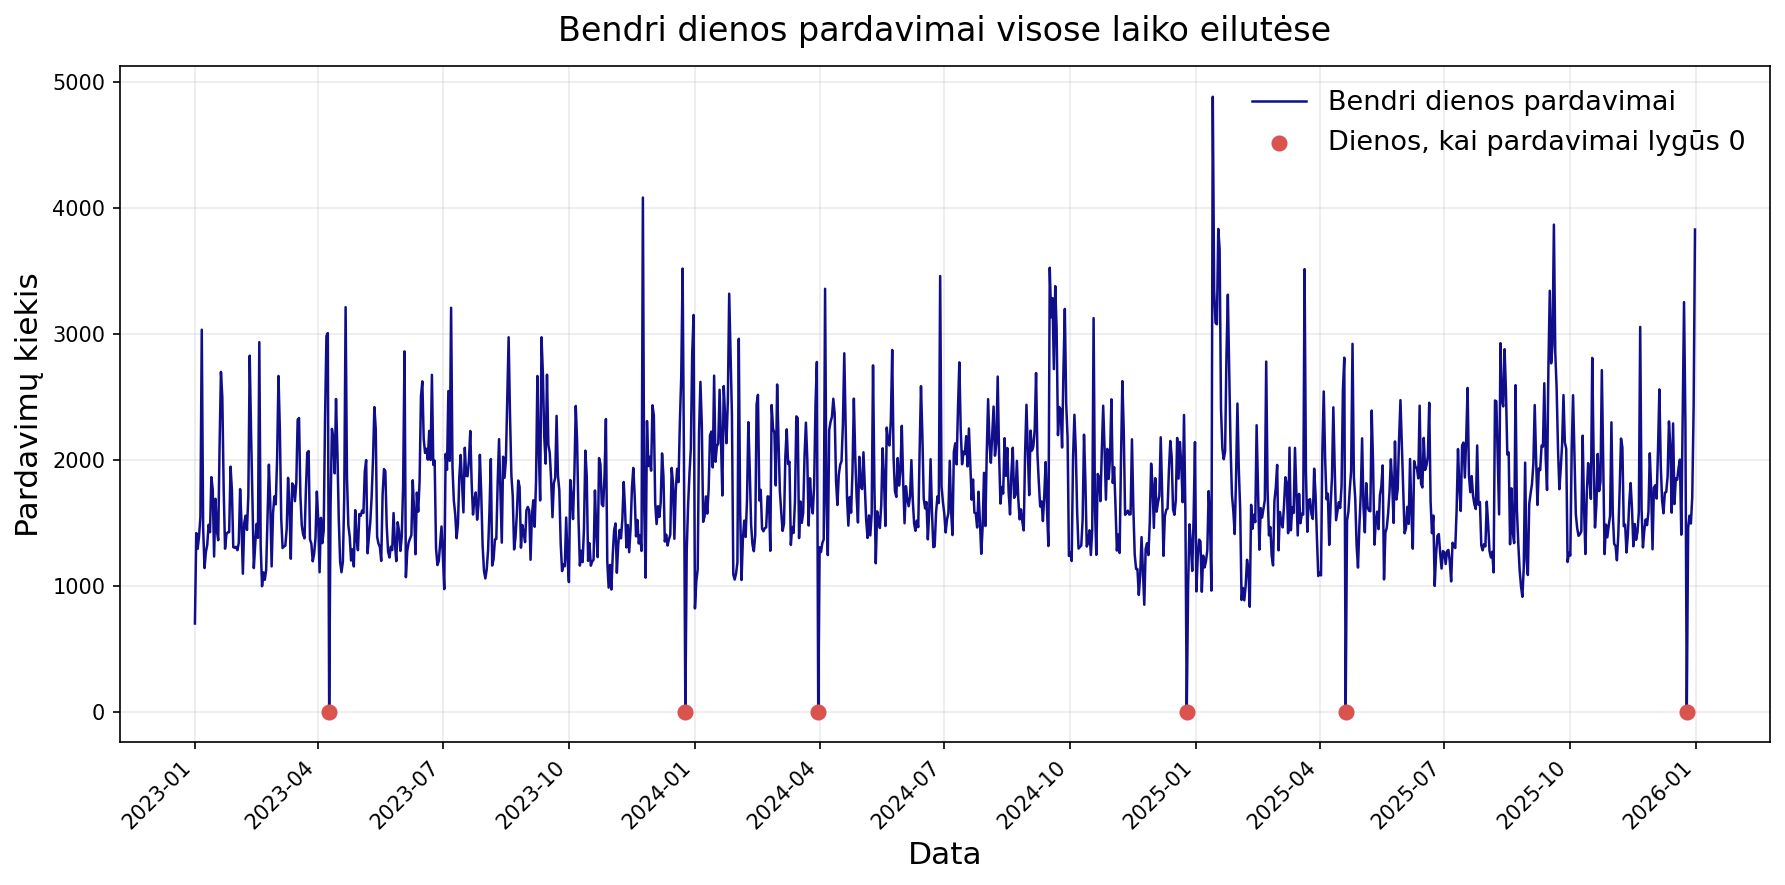

In [7]:
daily_total = (
    main
    .groupby("ds", as_index=False)
    .agg(total_sales=("y", "sum"))
)
zero_days = daily_total[daily_total["total_sales"] == 0]
plt.figure(figsize=(12, 6), dpi=150)
plt.plot(
    daily_total["ds"],
    daily_total["total_sales"],
    color="#100E8A",
    linewidth=1.2,
    label="Bendri dienos pardavimai"
)
plt.scatter(
    zero_days["ds"],
    zero_days["total_sales"],
    color="#D9534F",
    s=45,
    zorder=5,
    label="Dienos, kai pardavimai lygūs 0"
)
plt.title("Bendri dienos pardavimai visose laiko eilutėse", fontsize=16, pad=12)
plt.xlabel("Data", fontsize=15)
plt.ylabel("Pardavimų kiekis", fontsize=15)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, ha="right")
plt.grid(True, alpha=0.25)
plt.legend(frameon=False, fontsize=13)
plt.tight_layout()
plt.show()

Tikrinamas laiko eilučių stacionarumas.


In [8]:
main = main.sort_values(["STORE_ID", "SKU_ID", "DATE"]).reset_index(drop=True)

def is_stationary_adf(series):
    """ADF: p < 0.05  →  stationary (reject unit-root null)"""
    clean = series.dropna()
    result = adfuller(clean, autolag="AIC")
    return result[1] < 0.05

def is_stationary_kpss(series):
    """KPSS: p > 0.05  →  stationary (fail to reject stationarity null)"""
    clean = series.dropna()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = kpss(clean, regression="c", nlags="auto")
    return result[1] > 0.05

groups = main.groupby("unique_id")

both_stationary   = 0
adf_only_nonstat  = 0
kpss_only_nonstat = 0
both_nonstationary = 0

skipped = 0
results = []

for unique_id, grp in groups:
    y = grp.sort_values("DATE")["SALES_QTY"].astype(float)

    adf_stat  = is_stationary_adf(y)
    kpss_stat = is_stationary_kpss(y)

    if adf_stat is None or kpss_stat is None:
        skipped += 1
        continue

    if adf_stat and kpss_stat:
        both_stationary    += 1
        verdict = "Both stationary"
    elif not adf_stat and kpss_stat:
        adf_only_nonstat   += 1
        verdict = "ADF non-stationary only"
    elif adf_stat and not kpss_stat:
        kpss_only_nonstat  += 1
        verdict = "KPSS non-stationary only"
    else:
        both_nonstationary += 1
        verdict = "Both non-stationary"

    results.append({"unique_id": unique_id, "verdict": verdict,
                     "adf_stationary": adf_stat, "kpss_stationary": kpss_stat})

total_tested = both_stationary + adf_only_nonstat + kpss_only_nonstat + both_nonstationary

print("=" * 55)
print(f"Series tested : {total_tested}   |   Skipped (too short): {skipped}")
print("=" * 55)
print(f"Both stationary          : {both_stationary:>4}  ({both_stationary/total_tested*100:.1f}%)")
print(f"ADF non-stat only        : {adf_only_nonstat:>4}  ({adf_only_nonstat/total_tested*100:.1f}%)  ← conflict")
print(f"KPSS non-stat only       : {kpss_only_nonstat:>4}  ({kpss_only_nonstat/total_tested*100:.1f}%)  ← conflict")
print(f"Both non-stationary      : {both_nonstationary:>4}  ({both_nonstationary/total_tested*100:.1f}%)")
print("=" * 55)
print(f"Any non-stationarity     : {adf_only_nonstat + kpss_only_nonstat + both_nonstationary:>4}  "
      f"(at least one test flagged)")

Series tested : 800   |   Skipped (too short): 0
Both stationary          :  469  (58.6%)
ADF non-stat only        :    0  (0.0%)  ← conflict
KPSS non-stat only       :  329  (41.1%)  ← conflict
Both non-stationary      :    2  (0.2%)
Any non-stationarity     :  331  (at least one test flagged)
